# 누적 복습 2. Linnerud 운동 데이터 회귀

## 난이도
- 간단한 복습 문제

## 데이터셋 설명
- `sklearn.datasets.load_linnerud()` 데이터셋을 사용함.
- 20명의 운동 수행 기록과 신체 측정값을 담은 작은 회귀 예제 데이터임.
- 입력 feature는 운동 수행량임.
  - `Chins`: 턱걸이 횟수
  - `Situps`: 윗몸일으키기 횟수
  - `Jumps`: 점프 횟수
- target은 신체 측정값 중 `Weight`를 사용함.

## 복습 범위
- 다중 선형 회귀
- Ridge 회귀
- Random Forest 회귀
- R2, RMSE 해석
- 실제값과 예측값 비교 시각화


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.display import display_latex

from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

linnerud = load_linnerud(as_frame=True)

exercise_df = linnerud.data.copy()
body_df = linnerud.target.copy()
linnerud_df = pd.concat([exercise_df, body_df], axis=1)

X = exercise_df
y = body_df['Weight']

print('데이터 크기:', linnerud_df.shape)
print('feature:', list(X.columns))
print('target: Weight')
display(linnerud_df.head())


데이터 크기: (20, 6)
feature: ['Chins', 'Situps', 'Jumps']
target: Weight


,Chins,Situps,Jumps,Weight,Waist,Pulse
0,5.0,162.0,60.0,191.0,36.0,50.0
1,2.0,110.0,60.0,189.0,37.0,52.0
2,12.0,101.0,101.0,193.0,38.0,58.0
3,12.0,105.0,37.0,162.0,35.0,62.0
4,13.0,155.0,58.0,189.0,35.0,46.0


## 문제 1. 회귀용 데이터 분리와 스케일링

운동 수행량으로 체중을 예측할 수 있도록 학습/평가 데이터를 나누고 스케일링하세요.

### 요구사항
- `train_test_split()` 사용
- `test_size=0.25`, `random_state=42` 사용
- `StandardScaler()` 사용
- 학습 데이터에는 `fit_transform()`, 평가 데이터에는 `transform()` 사용
- 분리 결과 shape 출력

### 힌트
- 데이터 수가 20개로 매우 작으므로 점수 변동이 클 수 있음.
- 작은 데이터에서는 평가 결과를 절대적인 성능으로 해석하기보다 실습 흐름 이해에 초점을 둠.


In [5]:
# 작성: train_test_split()으로 학습/평가 데이터를 분리하세요.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 작성: StandardScaler()로 학습/평가 데이터를 스케일링하세요.
scaler = StandardScaler()
# X_train으로 스케일 기준을 만들고 변환
X_train_scaled = scaler.fit_transform(X_train)
# X_train에서 만든 기준으로 X_test도 변환
X_test_scaled = scaler.transform(X_test)

# 작성: 분리 결과 shape를 출력하세요.
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(15, 3) (5, 3)
(15,) (5,)


## 문제 2. 회귀 모델 3개 성능 비교

Linear Regression, Ridge, Random Forest Regressor를 학습하고 R2와 RMSE를 비교하세요.

### 요구사항
- `LinearRegression()` 사용
- `Ridge(alpha=1.0)` 사용
- `RandomForestRegressor(n_estimators=200, random_state=42)` 사용
- 결과 컬럼: `model`, `train_R2`, `test_R2`, `test_RMSE`
- 결과를 DataFrame으로 출력

### 힌트
- R2는 높을수록 좋고, RMSE는 낮을수록 좋음.
- 작은 데이터에서는 Random Forest가 훈련 데이터를 잘 맞추더라도 평가 성능이 안정적이지 않을 수 있음.


In [6]:
# 작성: Linear Regression, Ridge, Random Forest Regressor 모델을 준비하세요.
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=200, random_state=42),
}

# 작성: 반복문으로 모델을 학습하고 R2/RMSE를 results에 저장하세요.
results = []
for name, model in models.items():
    # 모델을 학습
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    # 학습된 모델들이 R2/RMSE result 저장

    results.append({
        'model': name,
        'train_R2': model.score(X_train_scaled, y_train),
        'test_R2': model.score(X_test_scaled, y_test),
        'test_RMSE': root_mean_squared_error(y_test, y_test_pred),
    })

# 작성: 결과를 DataFrame으로 출력하세요.
result_df = pd.DataFrame(results)
display(result_df)


,model,train_R2,test_R2,test_RMSE
0,LinearRegression,0.398504,-2.227171,27.667399
1,Ridge,0.387999,-1.489925,24.302475
2,RandomForestRegressor,0.839990,-1.519587,24.446801


## 문제 3. 새 운동 기록의 체중 예측과 그래프 확인

평가 RMSE가 가장 낮은 모델을 선택해 새 운동 기록의 체중을 예측하고, 실제값과 예측값을 산점도로 비교하세요.

### 요구사항
- 가장 낮은 `test_RMSE` 모델 선택
- 새 데이터 2개 예측
- 평가 데이터의 실제값과 예측값 산점도 그리기

### 힌트
- 새 데이터도 학습 데이터 기준으로 만든 scaler로 `transform()` 해야 함.
- 실제값과 예측값이 비슷하면 산점도가 대각선 근처에 놓임.


/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47800 (\N{HANGUL SYLLABLE MOM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font

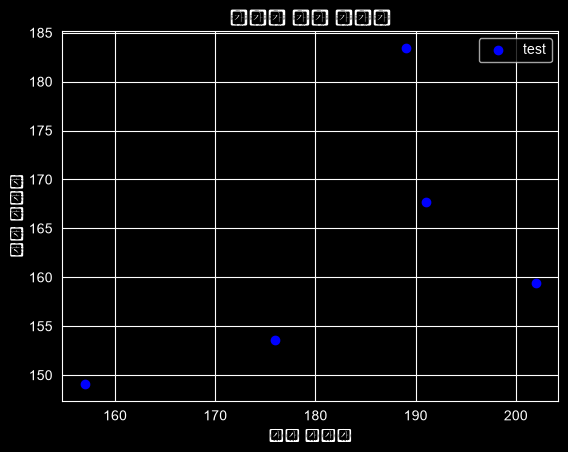

In [14]:
# 작성: result_df에서 test_RMSE가 가장 낮은 모델을 선택하세요.
w_model_name = result_df.loc[result_df['test_RMSE'].idxmin()]['model']
w_model = models[w_model_name]

# 작성: 새 운동 기록 2개를 DataFrame으로 만들고 스케일링 후 예측하세요.
new_exercise = pd.DataFrame({
    'Chins': [8, 15],
    'Situps': [90, 120],
    'Jumps': [40, 55]
})

new_exercise_scaled = scaler.transform(new_exercise)
new_weight_pred = w_model.predict(new_exercise_scaled)

# print(new_weight)
# print(y_test)

# 작성: 평가 데이터 실제값과 예측값을 산점도로 시각화하세요.

# 평가 데이터 예측값
y_test_pred = w_model.predict(X_test_scaled)

# 평가 데이터 실제값과 예측값 산점도
plt.scatter(y_test, y_test_pred, color='blue', label='test')
plt.xlabel('예상 몸무게')
plt.ylabel('실제 몸무게')
plt.title('실제와 예상 무무게')
plt.legend()
plt.show()

